## Ahmad Raza
## 21i-1714
## Data Mining Lab

### Task 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
def load_and_preprocess_data(file_path):
    # Load the data
    df = pd.read_csv(file_path)
    
    # Convert categorical data (Gender) to numerical
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    
    # Select relevant features
    X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, df

In [3]:
def find_optimal_k(X_scaled, max_k=10):
    wcss = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    # Plot the elbow curve
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linewidth=2, markersize=8)
    plt.title('Elbow Method for Optimal K', fontsize=14, pad=20)
    plt.xlabel('Number of clusters (K)', fontsize=12)
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    return wcss

In [4]:
def perform_clustering(X_scaled, k=5):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    return clusters, kmeans

In [5]:
def visualize_clusters(df, clusters):
    # Set style
    sns.set_style("whitegrid")
    sns.set_palette("viridis")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Customer Segmentation Analysis', fontsize=16, y=1.02)
    
    # Plot 1: Income vs Spending Score
    sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                   hue=clusters, s=100, ax=axes[0, 0])
    axes[0, 0].set_title('Income vs Spending Score', fontsize=14)
    axes[0, 0].set_xlabel('Annual Income (k$)', fontsize=12)
    axes[0, 0].set_ylabel('Spending Score (1-100)', fontsize=12)
    
    # Plot 2: Age vs Spending Score
    sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)',
                   hue=clusters, s=100, ax=axes[0, 1])
    axes[0, 1].set_title('Age vs Spending Score', fontsize=14)
    axes[0, 1].set_xlabel('Age', fontsize=12)
    axes[0, 1].set_ylabel('Spending Score (1-100)', fontsize=12)
    
    # Plot 3: Age vs Income
    sns.scatterplot(data=df, x='Age', y='Annual Income (k$)',
                   hue=clusters, s=100, ax=axes[1, 0])
    axes[1, 0].set_title('Age vs Income', fontsize=14)
    axes[1, 0].set_xlabel('Age', fontsize=12)
    axes[1, 0].set_ylabel('Annual Income (k$)', fontsize=12)
    
    # Plot 4: Gender Distribution per Cluster
    gender_cluster = pd.crosstab(df['Gender'], clusters)
    gender_cluster.plot(kind='bar', stacked=True, ax=axes[1, 1])
    axes[1, 1].set_title('Gender Distribution per Cluster', fontsize=14)
    axes[1, 1].set_xlabel('Gender', fontsize=12)
    axes[1, 1].set_ylabel('Count', fontsize=12)
    axes[1, 1].set_xticklabels(['Male', 'Female'], rotation=0)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
    
    # Create box plots for each feature
    plt.figure(figsize=(15, 10))
    features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    
    for i, feature in enumerate(features, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x=clusters, y=df[feature])
        plt.title(f'{feature} Distribution by Cluster', fontsize=14)
        plt.xlabel('Cluster', fontsize=12)
        plt.ylabel(feature, fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [6]:
def main():
    # Load and preprocess data
    X_scaled, df = load_and_preprocess_data('Mall_Customers.csv')
    
    # Find optimal K
    wcss = find_optimal_k(X_scaled)
    
    # Perform clustering with optimal K (let's use 5 as an example)
    clusters, kmeans = perform_clustering(X_scaled, k=5)
    
    # Add cluster labels to original dataframe
    df['Cluster'] = clusters
    
    # Visualize clusters
    visualize_clusters(df, clusters)
    
    # Print cluster statistics
    print("\nCluster Statistics:")
    print(df.groupby('Cluster').agg({
        'Age': 'mean',
        'Annual Income (k$)': 'mean',
        'Spending Score (1-100)': 'mean',
        'Gender': lambda x: (x == 1).mean()  # Proportion of females
    }).round(2))

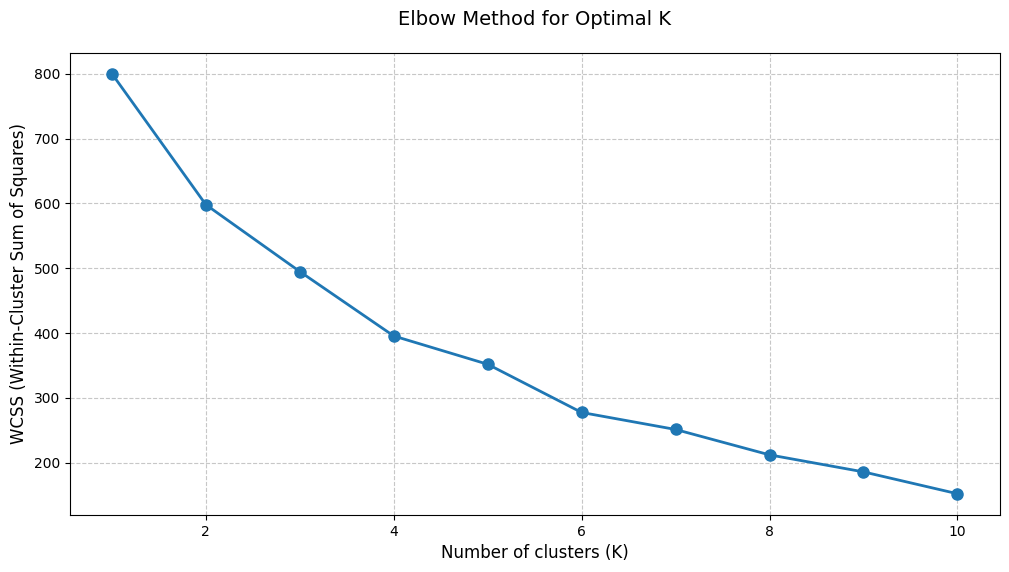

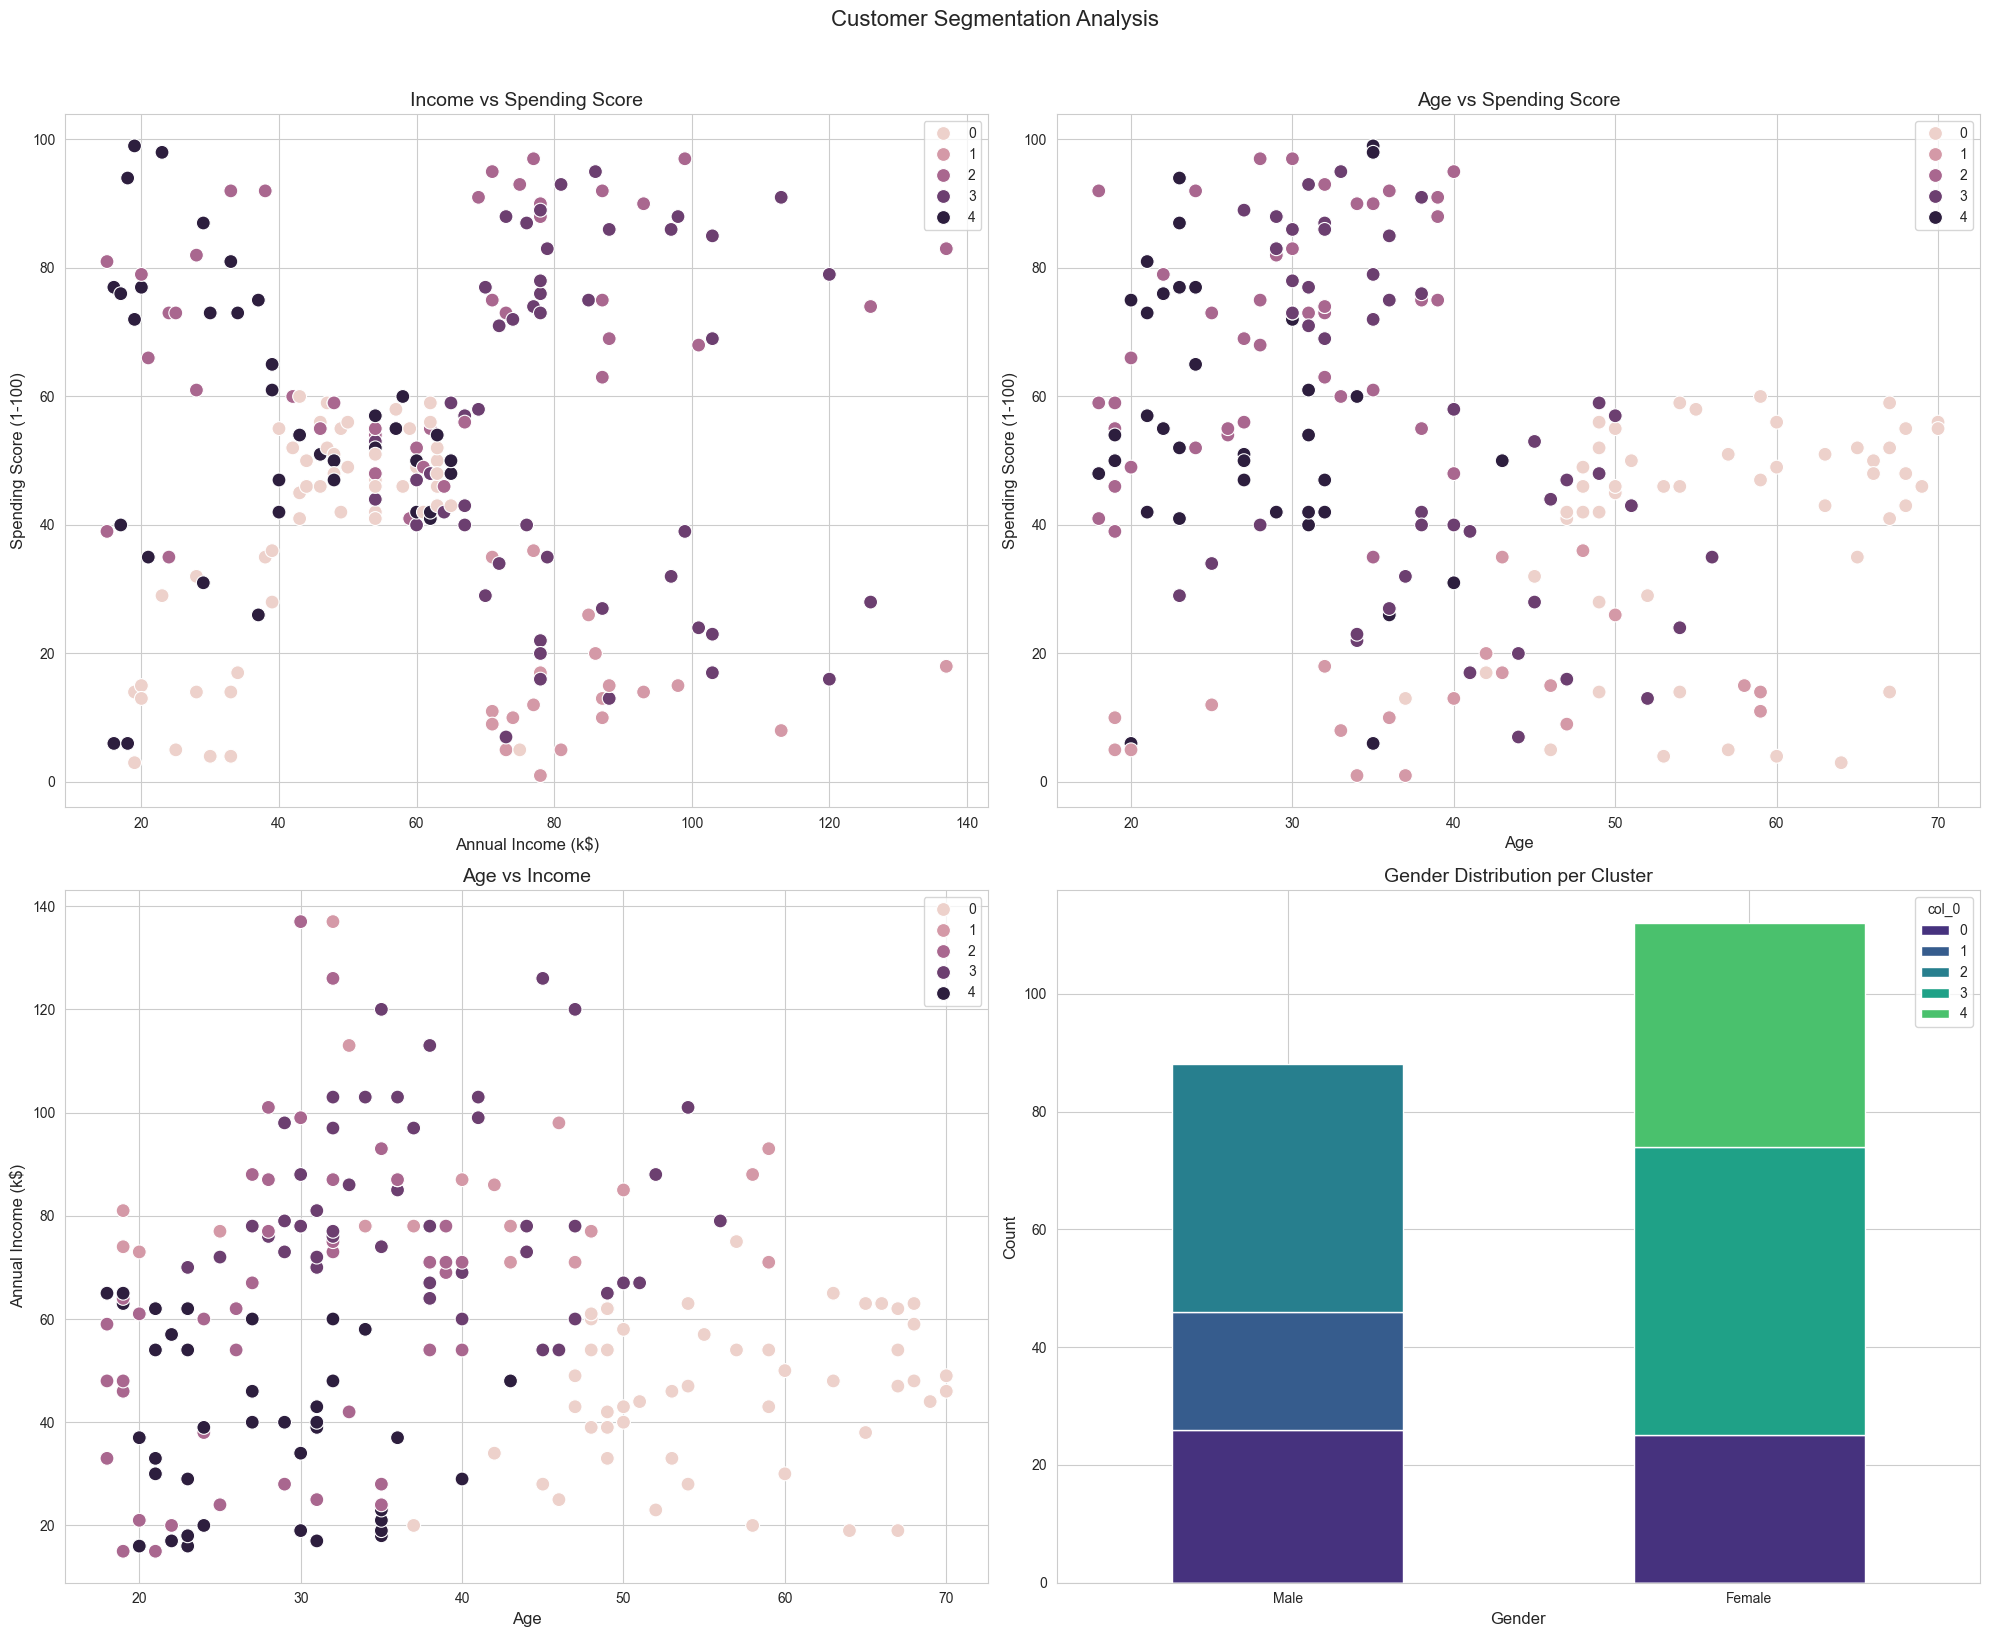

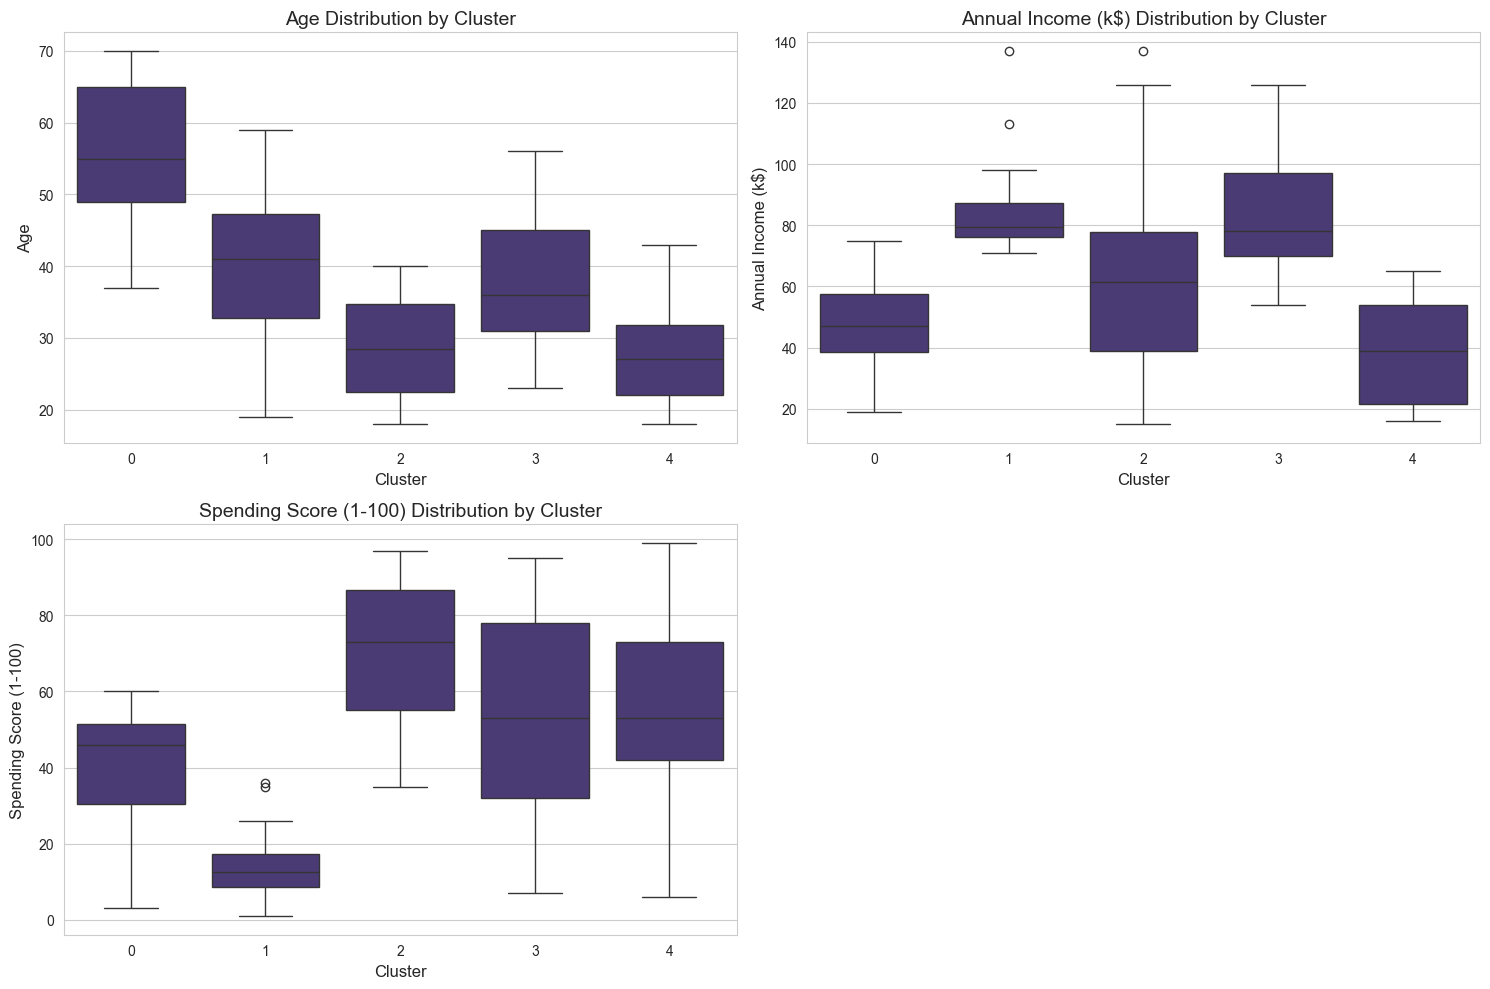


Cluster Statistics:
           Age  Annual Income (k$)  Spending Score (1-100)  Gender
Cluster                                                           
0        56.47               46.10                   39.31    0.49
1        39.50               85.15                   14.05    0.00
2        28.69               60.90                   70.24    0.00
3        37.90               82.12                   54.45    1.00
4        27.32               38.84                   56.21    1.00


In [7]:
if __name__ == "__main__":
    main()

### Task 2

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime

In [9]:
def load_and_preprocess_data(file_path):
    # Load the data
    df = pd.read_excel(file_path)
    
    # Handle missing values
    df = df.dropna()
    
    # Convert InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    
    # Create RFM features
    # Recency: Days since last purchase
    # Frequency: Number of transactions
    # Monetary: Total amount spent
    current_date = df['InvoiceDate'].max()
    
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (current_date - x.max()).days,  # Recency
        'InvoiceNo': 'count',  # Frequency
        'Quantity': 'sum',  # Monetary
    }).reset_index()
    
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
    
    return X_scaled, rfm

In [10]:
def find_optimal_k(X_scaled, max_k=10):
    wcss = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    # Plot the elbow curve
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linewidth=2, markersize=8)
    plt.title('Elbow Method for Optimal K', fontsize=14, pad=20)
    plt.xlabel('Number of clusters (K)', fontsize=12)
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    return wcss

In [11]:
def perform_clustering(X_scaled, k=4):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    return clusters, kmeans

In [12]:
def visualize_clusters(rfm, clusters):
    # Set style
    sns.set_style("whitegrid")
    sns.set_palette("viridis")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Customer RFM Analysis', fontsize=16, y=1.02)
    
    # Plot 1: Recency vs Frequency
    sns.scatterplot(data=rfm, x='Recency', y='Frequency',
                   hue=clusters, s=100, ax=axes[0, 0])
    axes[0, 0].set_title('Recency vs Frequency', fontsize=14)
    axes[0, 0].set_xlabel('Recency (days)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    
    # Plot 2: Recency vs Monetary
    sns.scatterplot(data=rfm, x='Recency', y='Monetary',
                   hue=clusters, s=100, ax=axes[0, 1])
    axes[0, 1].set_title('Recency vs Monetary', fontsize=14)
    axes[0, 1].set_xlabel('Recency (days)', fontsize=12)
    axes[0, 1].set_ylabel('Monetary Value', fontsize=12)
    
    # Plot 3: Frequency vs Monetary
    sns.scatterplot(data=rfm, x='Frequency', y='Monetary',
                   hue=clusters, s=100, ax=axes[1, 0])
    axes[1, 0].set_title('Frequency vs Monetary', fontsize=14)
    axes[1, 0].set_xlabel('Frequency', fontsize=12)
    axes[1, 0].set_ylabel('Monetary Value', fontsize=12)
    
    # Plot 4: Customer Distribution
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    cluster_counts.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Customer Distribution per Cluster', fontsize=14)
    axes[1, 1].set_xlabel('Cluster', fontsize=12)
    axes[1, 1].set_ylabel('Number of Customers', fontsize=12)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
    
    # Create box plots for each feature
    plt.figure(figsize=(15, 10))
    features = ['Recency', 'Frequency', 'Monetary']
    
    for i, feature in enumerate(features, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x=clusters, y=rfm[feature])
        plt.title(f'{feature} Distribution by Cluster', fontsize=14)
        plt.xlabel('Cluster', fontsize=12)
        plt.ylabel(feature, fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [13]:
def analyze_clusters(rfm, clusters):
    # Add cluster labels to RFM dataframe
    rfm['Cluster'] = clusters
    
    # Print cluster statistics
    print("\nCluster Statistics:")
    cluster_stats = rfm.groupby('Cluster').agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean',
        'CustomerID': 'count'
    }).round(2)
    
    # Rename columns for better readability
    cluster_stats.columns = ['Avg Recency (days)', 'Avg Frequency', 'Avg Monetary', 'Customer Count']
    print(cluster_stats)
    
    # Calculate percentage of customers in each cluster
    print("\nCustomer Distribution:")
    print((rfm['Cluster'].value_counts(normalize=True) * 100).round(2))

In [14]:
def main():
    # Load and preprocess data
    X_scaled, rfm = load_and_preprocess_data('Online Retail.xlsx')
    
    # Find optimal K
    wcss = find_optimal_k(X_scaled)
    
    # Perform clustering with optimal K (let's use 4 as an example)
    clusters, kmeans = perform_clustering(X_scaled, k=4)
    
    # Visualize clusters
    visualize_clusters(rfm, clusters)
    
    # Analyze clusters
    analyze_clusters(rfm, clusters)



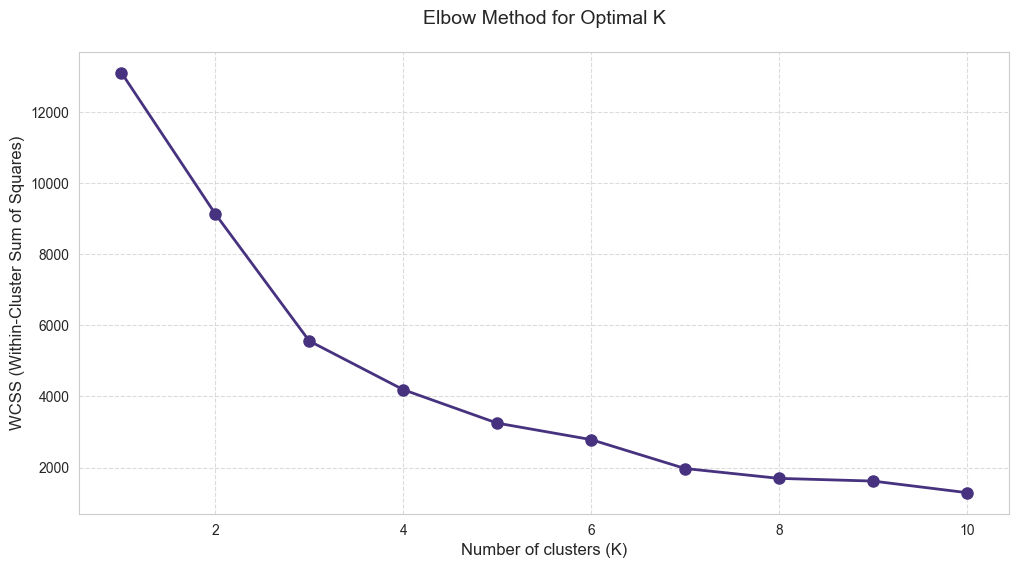

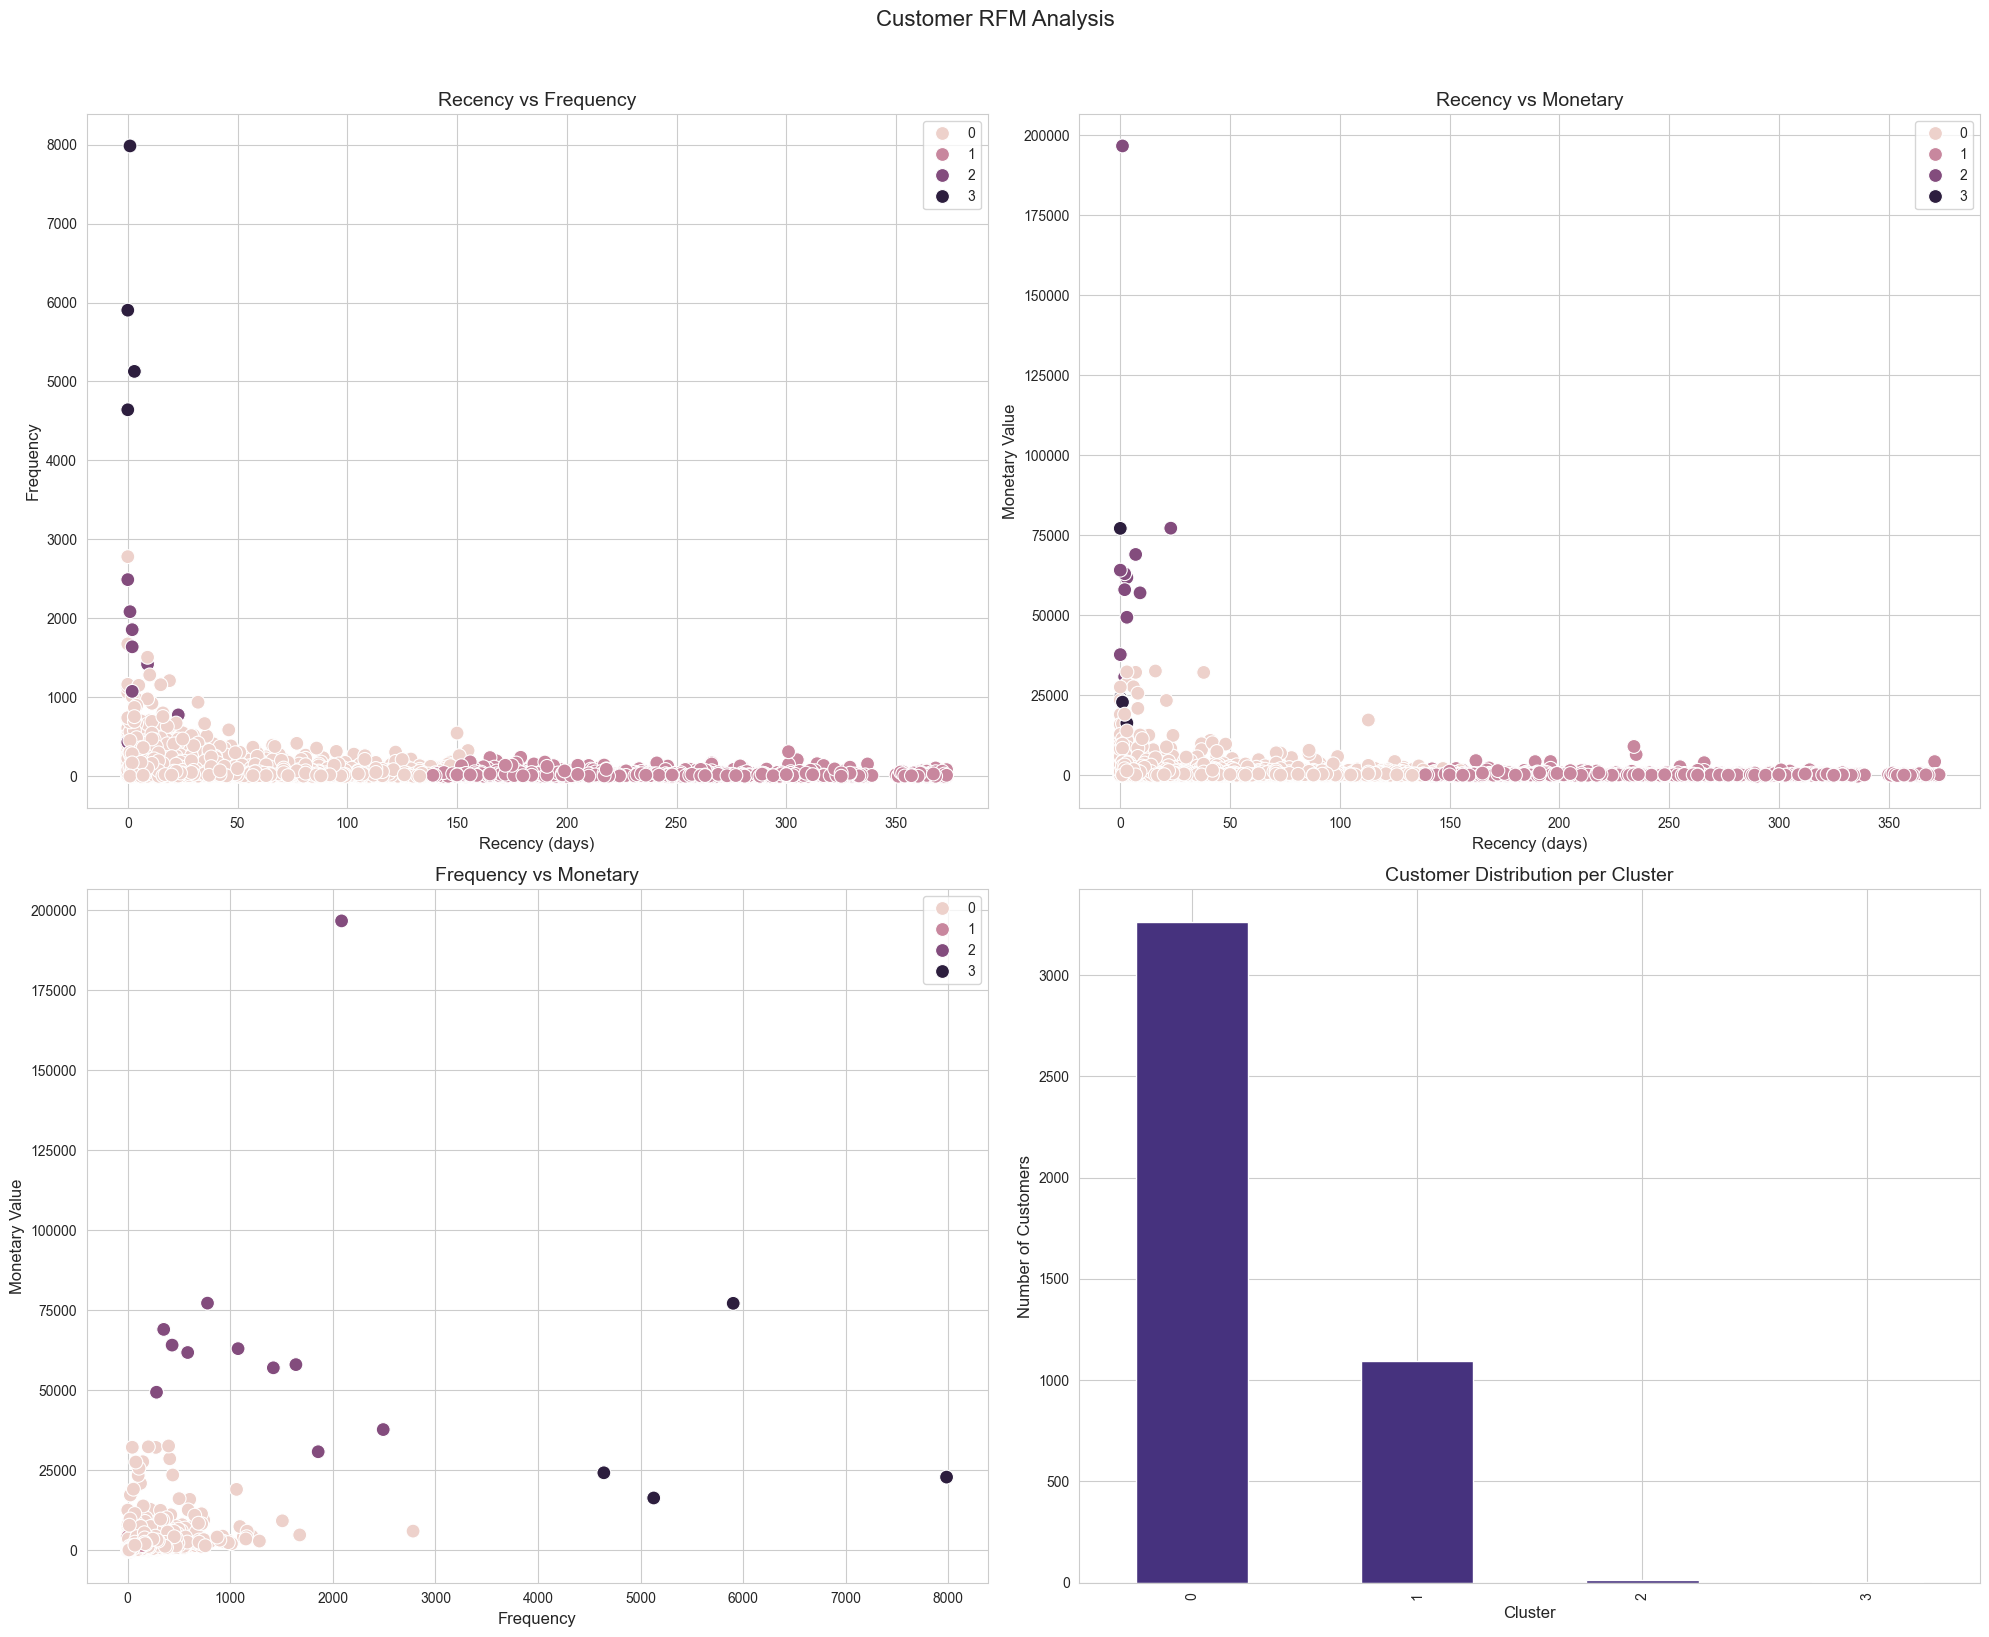

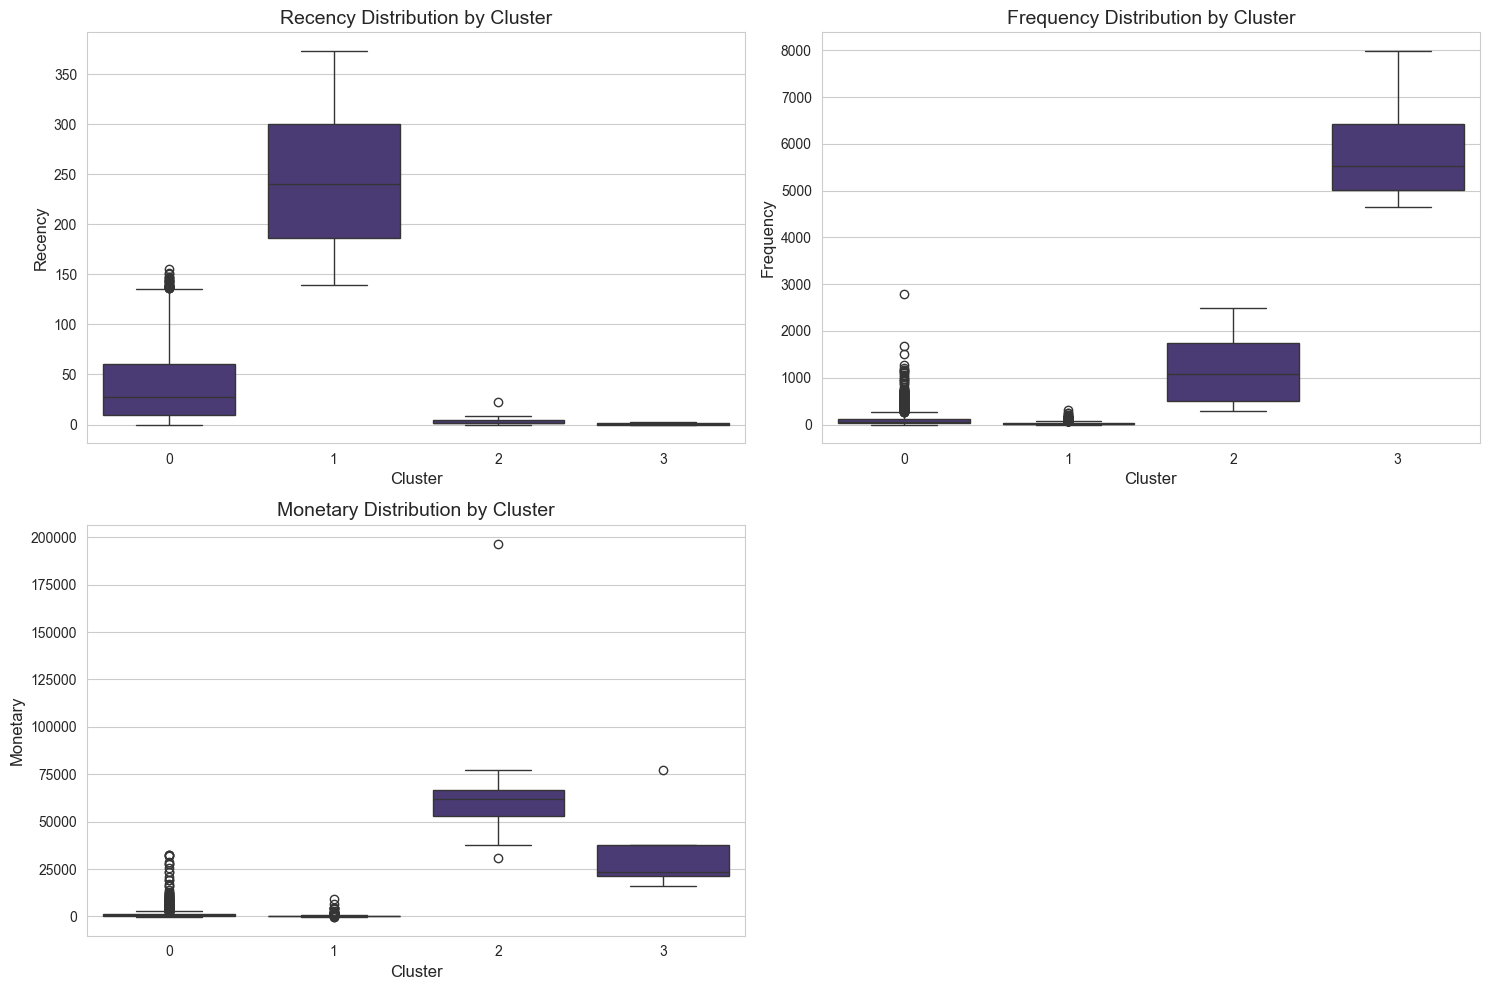


Cluster Statistics:
         Avg Recency (days)  Avg Frequency  Avg Monetary  Customer Count
Cluster                                                                 
0                     39.29         104.20       1139.45            3261
1                    246.24          27.71        260.65            1096
2                      4.73        1181.55      69533.64              11
3                      1.00        5914.00      35147.50               4

Customer Distribution:
Cluster
0    74.59
1    25.07
2     0.25
3     0.09
Name: proportion, dtype: float64


In [15]:
if __name__ == "__main__":
    main() 